!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [ ]:
import joblib
import pandas as pd

# Load model and metadata (only once per session)
model = joblib.load("house_price_model.joblib")
meta = joblib.load("model_metadata.joblib")

def predict_house_price(
    date="2020-01-01",
    bedrooms=3,
    bathrooms=2,
    sqft_living=1500,
    sqft_lot=3000,
    floors=1.0,
    waterfront=0,
    view=0,
    condition=3,
    sqft_above=1200,
    sqft_basement=300,
    yr_built=2000,
    yr_renovated=0,
    street="123 Main St",
    city="Seattle",
    statezip="WA 98101",
    country="USA"
):
    row = {
        "date": date,
        "bedrooms": bedrooms,
        "bathrooms": bathrooms,
        "sqft_living": sqft_living,
        "sqft_lot": sqft_lot,
        "floors": floors,
        "waterfront": waterfront,
        "view": view,
        "condition": condition,
        "sqft_above": sqft_above,
        "sqft_basement": sqft_basement,
        "yr_built": yr_built,
        "yr_renovated": yr_renovated,
        "street": street,
        "city": city,
        "statezip": statezip,
        "country": country,
    }

    new_house = pd.DataFrame([row])[meta["feature_cols"]]
    predicted_price = model.predict(new_house)[0]
    return predicted_price

# Example: test with a new house
price = predict_house_price(
    bedrooms=4,
    bathrooms=3,
    sqft_living=2200,
    sqft_lot=4000,
    floors=2.0,
    yr_built=2015,
    city="Bellevue",
    statezip="WA 98004"
)
print(f"Predicted house price: {price:.2f}")

FileNotFoundError: [Errno 2] No such file or directory: 'house_price_model.joblib'

In [ ]:
# Install only if needed (in Colab or fresh env)
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Load dataset (adjust path if you downloaded locally)
df = pd.read_csv("house_price_prediction.csv")  # or your actual filename

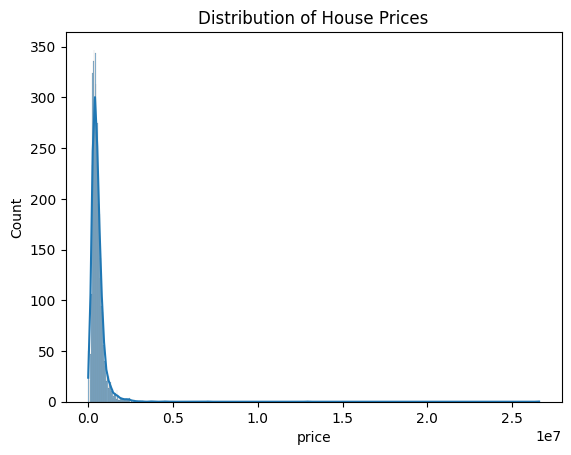

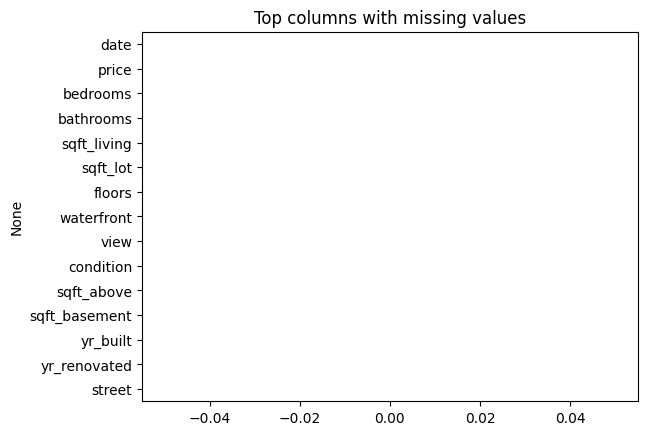

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
Name: price, dtype: float64


In [ ]:
# Target variable
target = "price"  # CHANGE to the actual price column name in your dataset
sns.histplot(df[target], kde=True)
plt.title("Distribution of House Prices")
plt.show()

# Missing values heatmap (top columns)
missing = df.isna().mean().sort_values(ascending=False).head(15)
sns.barplot(x=missing.values, y=missing.index)
plt.title("Top columns with missing values")
plt.show()

# Correlation with target (numeric only)
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()[target].sort_values(ascending=False)
print(corr.head(10))

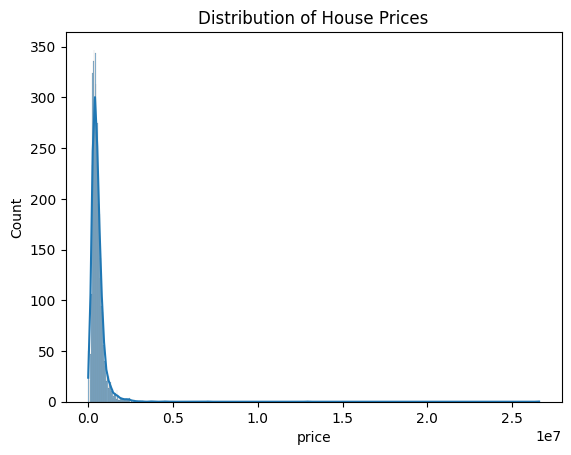

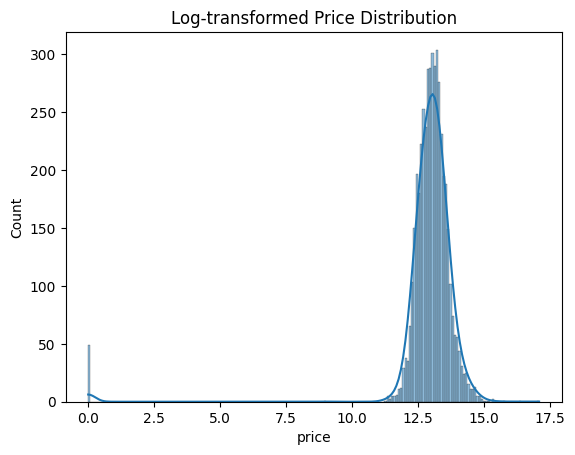

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

target = "price"  # change to your actual target column name

# 1. Original price distribution
sns.histplot(df[target], kde=True)
plt.title("Distribution of House Prices")
plt.show()

# 2. Log-transformed price distribution (check skewness)
sns.histplot(np.log1p(df[target]), kde=True)
plt.title("Log-transformed Price Distribution")
plt.show()

In [ ]:
# Example: drop obvious non-features
drop_cols = ["id", "url", "address"]  # adjust to your dataset
feature_cols = [c for c in df.columns if c != target and c not in drop_cols]

X = df[feature_cols]
y = df[target]
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

In [ ]:
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [ ]:
y_train_model = np.log1p(y)  # use this instead of y if distribution is skewed

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# y_train_model = np.log1p(y_train)
# y_test_model = np.log1p(y_test)

In [ ]:
lr_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

gb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    ))
])

models = {
    "Linear Regression": lr_pipe,
    "Random Forest": rf_pipe,
    "Gradient Boosting": gb_pipe
}

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "model": name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })
    print(f"{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.3f}")

results_df = pd.DataFrame(results)
print(results_df.sort_values("rmse"))

TypeError: got an unexpected keyword argument 'squared'

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "model": name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })
    print(f"{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.3f}")

results_df = pd.DataFrame(results)
print(results_df.sort_values("rmse"))

Linear Regression: RMSE=1073211.70, MAE=302645.66, R²=-0.129
Random Forest: RMSE=984252.59, MAE=155984.67, R²=0.050
Gradient Boosting: RMSE=981034.94, MAE=148789.23, R²=0.056
               model          rmse            mae        r2
2  Gradient Boosting  9.810349e+05  148789.234740  0.056299
1      Random Forest  9.842526e+05  155984.666325  0.050099
0  Linear Regression  1.073212e+06  302645.657240 -0.129370


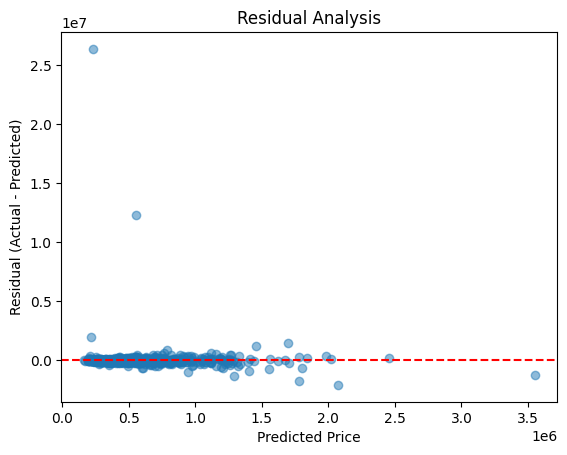

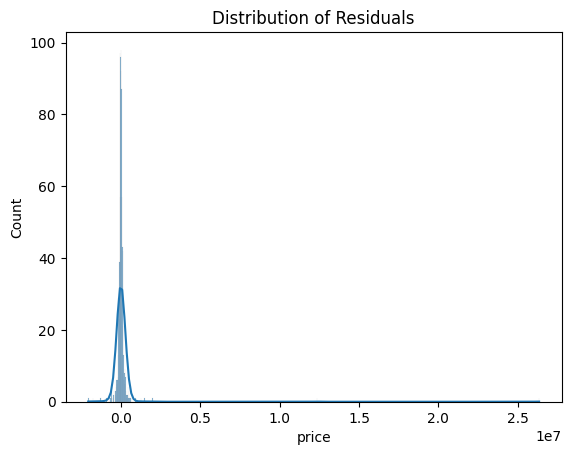

In [ ]:
best_model = gb_pipe  # or lr_pipe / rf_pipe depending on results
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

# Residuals vs predicted
plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis")
plt.show()

# Residual distribution
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

In [ ]:
fitted_pipe = best_model  # must be RF or GB
encoder = fitted_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
ohe_feature_names = encoder.get_feature_names_out(cat_cols)

all_feature_names = np.concatenate([num_cols, ohe_feature_names])

importances = fitted_pipe.named_steps["model"].feature_importances_
feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_imp.head(15))

                     feature  importance
2                sqft_living    0.540032
3764       statezip_WA 98004    0.046909
6                       view    0.031512
8                 sqft_above    0.027721
10                  yr_built    0.026900
3752            city_Seattle    0.025091
3721           city_Bellevue    0.019450
3785       statezip_WA 98039    0.014214
5                 waterfront    0.013741
3                   sqft_lot    0.013089
3814       statezip_WA 98112    0.011327
3739             city_Medina    0.010676
1                  bathrooms    0.009253
3786       statezip_WA 98040    0.009147
2070  street_2826 21st Ave W    0.008740


In [ ]:
joblib.dump(best_model, "house_price_model.joblib")
print("Model saved to house_price_model.joblib")

NameError: name 'best_model' is not defined

In [ ]:
joblib.dump({
    "feature_cols": feature_cols,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "target": target
}, "model_metadata.joblib")

['model_metadata.joblib']

In [ ]:
# Load model and metadata
model = joblib.load("house_price_model.joblib")
meta = joblib.load("model_metadata.joblib")

# Example new house (adjust fields to match your dataset columns)
new_house = pd.DataFrame([{
    "area": 1200,
    "bedrooms": 3,
    "bathrooms": 2,
    "location": "Koramangala",      # example categorical
    "age_years": 5,
    # ... add all other features your dataset has, with realistic values
}])

# Ensure columns are in the same order as training
new_house = new_house[meta["feature_cols"]]

predicted_price = model.predict(new_house)[0]
print(f"Predicted house price: {predicted_price:.2f}")

KeyError: "['date', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country'] not in index"

In [ ]:
import joblib
import pandas as pd

meta = joblib.load("model_metadata.joblib")
print(meta["feature_cols"])


['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']


In [ ]:
model = joblib.load("house_price_model.joblib")
meta = joblib.load("model_metadata.joblib")

# Example: adjust this dict to match your actual feature_cols and dataset
new_house = pd.DataFrame([{
    "area": 1200,
    "bedrooms": 3,
    "bathrooms": 2,
    "location": "Koramangala",
    "age_years": 5,
    # Add EVERY other feature from meta["feature_cols"] here
    # For numeric features, use typical values or 0/median
    # For categorical, use a valid category from your data
    # Example placeholders (replace with real column names):
    # "floor": 2,
    # "facing": "East",
    # "furnishing": "Unfurnished",
    # ...
}])

# Reorder columns exactly as in training
new_house = new_house[meta["feature_cols"]]

predicted_price = model.predict(new_house)[0]
print(f"Predicted house price: {predicted_price:.2f}")

KeyError: "['date', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country'] not in index"

In [ ]:
import joblib
import pandas as pd

meta = joblib.load("model_metadata.joblib")
print(meta["feature_cols"])

['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']


In [ ]:
import joblib
import pandas as pd

# Load model and metadata
model = joblib.load("house_price_model.joblib")
meta = joblib.load("model_metadata.joblib")

# Create a complete example house with ALL required features
new_house = pd.DataFrame([{
    "date": "2020-01-01",        # use same format as in dataset, e.g. "YYYY-MM-DD"
    "bedrooms": 3,
    "bathrooms": 2,
    "sqft_living": 1500,
    "sqft_lot": 3000,
    "floors": 1.0,
    "waterfront": 0,             # 0 = no waterfront, 1 = yes
    "view": 0,                   # e.g. 0–4 rating
    "condition": 3,              # e.g. 1–5 rating
    "sqft_above": 1200,
    "sqft_basement": 300,
    "yr_built": 2000,
    "yr_renovated": 0,           # 0 if never renovated
    "street": "123 Main St",
    "city": "Seattle",
    "statezip": "WA 98101",
    "country": "USA"
}])

# Reorder columns exactly as in training
new_house = new_house[meta["feature_cols"]]

predicted_price_log = model.predict(new_house)[0]
predicted_price = np.expm1(predicted_price_log)
print(f"Predicted house price: {predicted_price:.2f}")

Predicted house price: inf


/tmp/ipykernel_1160/1499680566.py:33: RuntimeWarning: overflow encountered in expm1
  predicted_price = np.expm1(predicted_price_log)


In [ ]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load("house_price_model.joblib")
meta = joblib.load("model_metadata.joblib")

new_house = pd.DataFrame([{
    "date": "2020-01-01",
    "bedrooms": 3,
    "bathrooms": 2,
    "sqft_living": 1500,
    "sqft_lot": 3000,
    "floors": 1.0,
    "waterfront": 0,
    "view": 0,
    "condition": 3,
    "sqft_above": 1200,
    "sqft_basement": 300,
    "yr_built": 2000,
    "yr_renovated": 0,
    "street": "123 Main St",
    "city": "Seattle",
    "statezip": "WA 98101",
    "country": "USA"
}])

new_house = new_house[meta["feature_cols"]]

pred_raw = model.predict(new_house)[0]
print("Raw model output:", pred_raw)

FileNotFoundError: [Errno 2] No such file or directory: 'house_price_model.joblib'

In [ ]:
import joblib
import pandas as pd

# Load model and metadata
model = joblib.load("house_price_model.joblib")
meta = joblib.load("model_metadata.joblib")

# Example house (adjust values as needed)
new_house = pd.DataFrame([{
    "date": "2020-01-01",
    "bedrooms": 3,
    "bathrooms": 2,
    "sqft_living": 1500,
    "sqft_lot": 3000,
    "floors": 1.0,
    "waterfront": 0,
    "view": 0,
    "condition": 3,
    "sqft_above": 1200,
    "sqft_basement": 300,
    "yr_built": 2000,
    "yr_renovated": 0,
    "street": "123 Main St",
    "city": "Seattle",
    "statezip": "WA 98101",
    "country": "USA"
}])

# Reorder columns exactly as in training
new_house = new_house[meta["feature_cols"]]

# Model predicts price directly (no log transform)
predicted_price = model.predict(new_house)[0]
print(f"Predicted house price: {predicted_price:.2f}")

Predicted house price: 439839.49


In [ ]:
import joblib
import pandas as pd

# Load model and metadata (only once per session)
model = joblib.load("house_price_model.joblib")
meta = joblib.load("model_metadata.joblib")

def predict_house_price(
    date="2020-01-01",
    bedrooms=3,
    bathrooms=2,
    sqft_living=1500,
    sqft_lot=3000,
    floors=1.0,
    waterfront=0,
    view=0,
    condition=3,
    sqft_above=1200,
    sqft_basement=300,
    yr_built=2000,
    yr_renovated=0,
    street="123 Main St",
    city="Seattle",
    statezip="WA 98101",
    country="USA"
):
    row = {
        "date": date,
        "bedrooms": bedrooms,
        "bathrooms": bathrooms,
        "sqft_living": sqft_living,
        "sqft_lot": sqft_lot,
        "floors": floors,
        "waterfront": waterfront,
        "view": view,
        "condition": condition,
        "sqft_above": sqft_above,
        "sqft_basement": sqft_basement,
        "yr_built": yr_built,
        "yr_renovated": yr_renovated,
        "street": street,
        "city": city,
        "statezip": statezip,
        "country": country,
    }

    new_house = pd.DataFrame([row])[meta["feature_cols"]]
    predicted_price = model.predict(new_house)[0]
    return predicted_price

# Example: test with a new house
price = predict_house_price(
    bedrooms=4,
    bathrooms=3,
    sqft_living=2200,
    sqft_lot=4000,
    floors=2.0,
    yr_built=2015,
    city="Bellevue",
    statezip="WA 98004"
)
print(f"Predicted house price: {price:.2f}")

Predicted house price: 779687.43


In [ ]:
import sklearn
sklearn.__version__


'1.6.1'